# Q2: Trajectories, Optimization & Selecting K

We now have a per-session progress score (0–3) for every client from Q1. These scores form a **cumulative progress trajectory** for each child across their 12-session care pathway.

This notebook:
1. Builds cumulative trajectories and clusters them with K-means
2. Derives an optimal reassessment policy using a newsvendor-style audit model
3. Selects the best K based on policy distinctness
4. Produces the required plots and summary table
5. Discusses implications for Westfield's care planning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load data
scored = pd.read_csv('../q1/scored_notes.csv')
features = pd.read_csv('../data/client_features.csv')
waitlist = pd.read_csv('../data/waitlist.csv')

# Filter to valid C_ clients only (exclude test artifacts)
scored = scored[scored['client_id'].str.startswith('C_')].copy()

print(f"Scored notes: {len(scored)} rows, {scored['client_id'].nunique()} clients")
print(f"Sessions: {sorted(scored['session'].unique())}")
print(f"Score distribution:\n{scored['score'].value_counts().sort_index()}")
print(f"\nClient features (unlabeled): {len(features[features['dataset_split']=='unlabeled'])} clients")
print(f"Waitlist: {len(waitlist)} clients")

Scored notes: 847 rows, 77 clients
Sessions: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Score distribution:
score
0    388
1    185
2    224
3     50
Name: count, dtype: int64

Client features (unlabeled): 77 clients
Waitlist: 35 clients


## Q2(a): Build the Clustering Model

**Approach:**
1. The per-session scores are already on the 0–3 scale
2. Construct **cumulative progress trajectories** across Sessions 1–12: Session 1 = 0 (baseline), each subsequent session adds the transition score
3. Apply K-means clustering for K = 2, 3, 4, 5, 6
4. Generate spaghetti plots for each K

In [3]:
# Build cumulative progress trajectories
# Session 1 = 0 (baseline), Session s = cumsum of scores through transition s-1 -> s
trajectories = {}
for cid, grp in scored.groupby('client_id'):
    grp = grp.sort_values('session')
    scores = grp['score'].values  # 11 transition scores (sessions 2-12)
    cumtraj = np.concatenate([[0], np.cumsum(scores)])  # 12-point trajectory
    trajectories[cid] = cumtraj

client_ids = sorted(trajectories.keys())
traj_matrix = np.array([trajectories[cid] for cid in client_ids])
sessions = np.arange(1, 13)

print(f"Trajectory matrix shape: {traj_matrix.shape}")
print(f"Cumulative score range: {traj_matrix[:, -1].min()} – {traj_matrix[:, -1].max()}")
print(f"Mean final cumulative: {traj_matrix[:, -1].mean():.2f}")

# Verify trajectories are non-decreasing
assert np.all(np.diff(traj_matrix, axis=1) >= 0), "Trajectories should be non-decreasing"
print("All trajectories are non-decreasing ✓")

Trajectory matrix shape: (77, 12)
Cumulative score range: 5 – 15
Mean final cumulative: 10.17
All trajectories are non-decreasing ✓


In [4]:
# K-Means clustering for K = 2, 3, 4, 5, 6
K_range = range(2, 7)
results = {}

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(traj_matrix)
    sil = silhouette_score(traj_matrix, labels)
    results[k] = {
        'model': km,
        'labels': labels,
        'inertia': km.inertia_,
        'silhouette': sil,
        'centers': km.cluster_centers_
    }
    sizes = [np.sum(labels == i) for i in range(k)]
    print(f"K={k}: silhouette={sil:.3f}, inertia={km.inertia_:.1f}, sizes={sizes}")

K=2: silhouette=0.499, inertia=873.3, sizes=[np.int64(35), np.int64(42)]
K=3: silhouette=0.405, inertia=565.6, sizes=[np.int64(32), np.int64(29), np.int64(16)]
K=4: silhouette=0.364, inertia=426.3, sizes=[np.int64(27), np.int64(21), np.int64(21), np.int64(8)]
K=5: silhouette=0.310, inertia=353.2, sizes=[np.int64(17), np.int64(24), np.int64(15), np.int64(13), np.int64(8)]
K=6: silhouette=0.292, inertia=308.5, sizes=[np.int64(8), np.int64(13), np.int64(11), np.int64(21), np.int64(6), np.int64(18)]


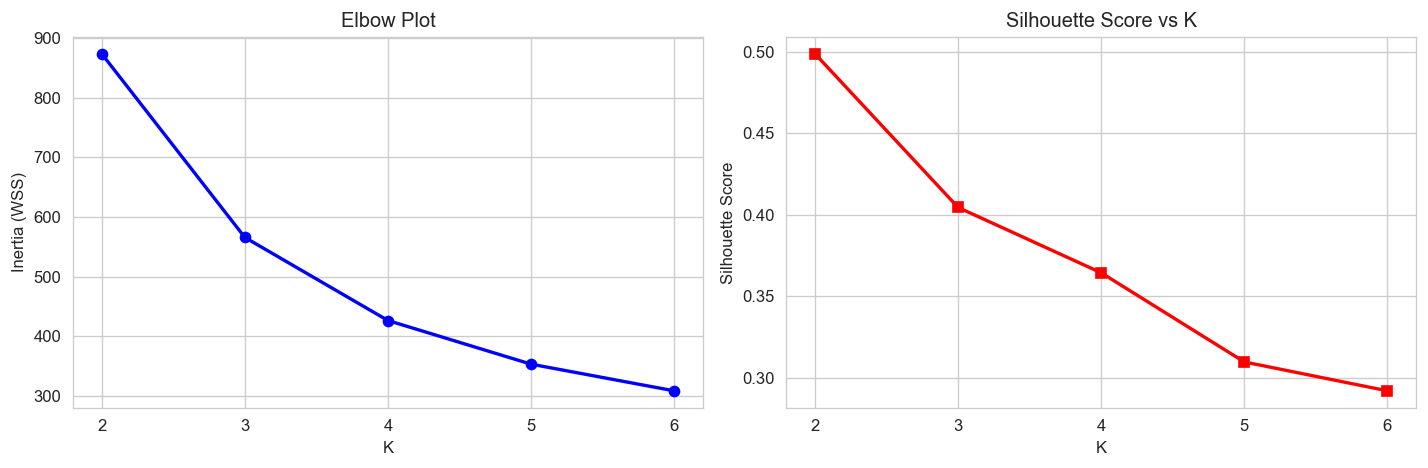

In [5]:
# Elbow plot and silhouette score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), [results[k]['inertia'] for k in K_range], 'bo-', linewidth=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WSS)')
axes[0].set_title('Elbow Plot')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), [results[k]['silhouette'] for k in K_range], 'rs-', linewidth=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

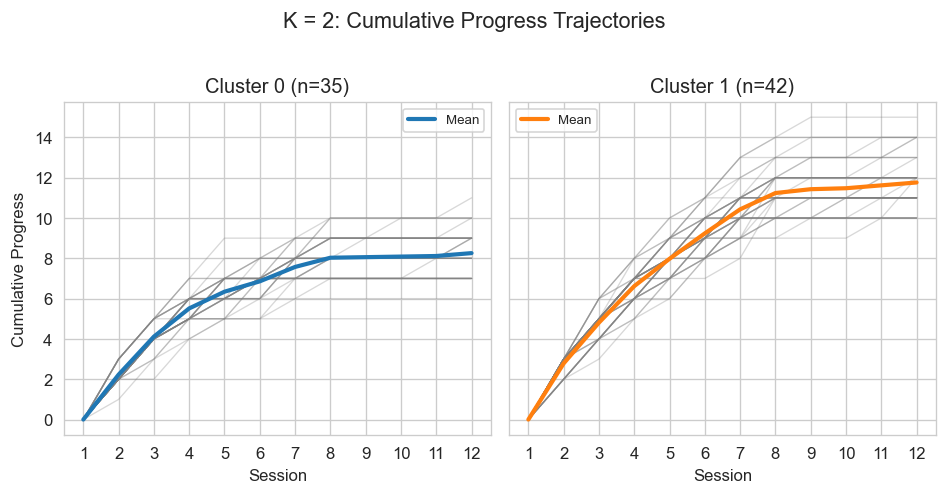

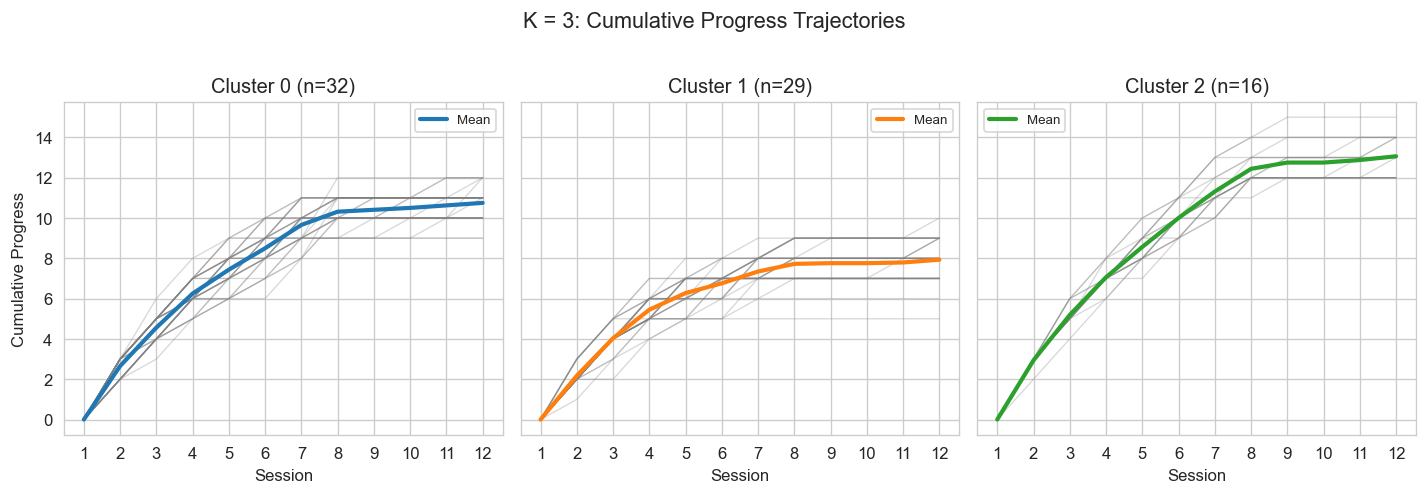

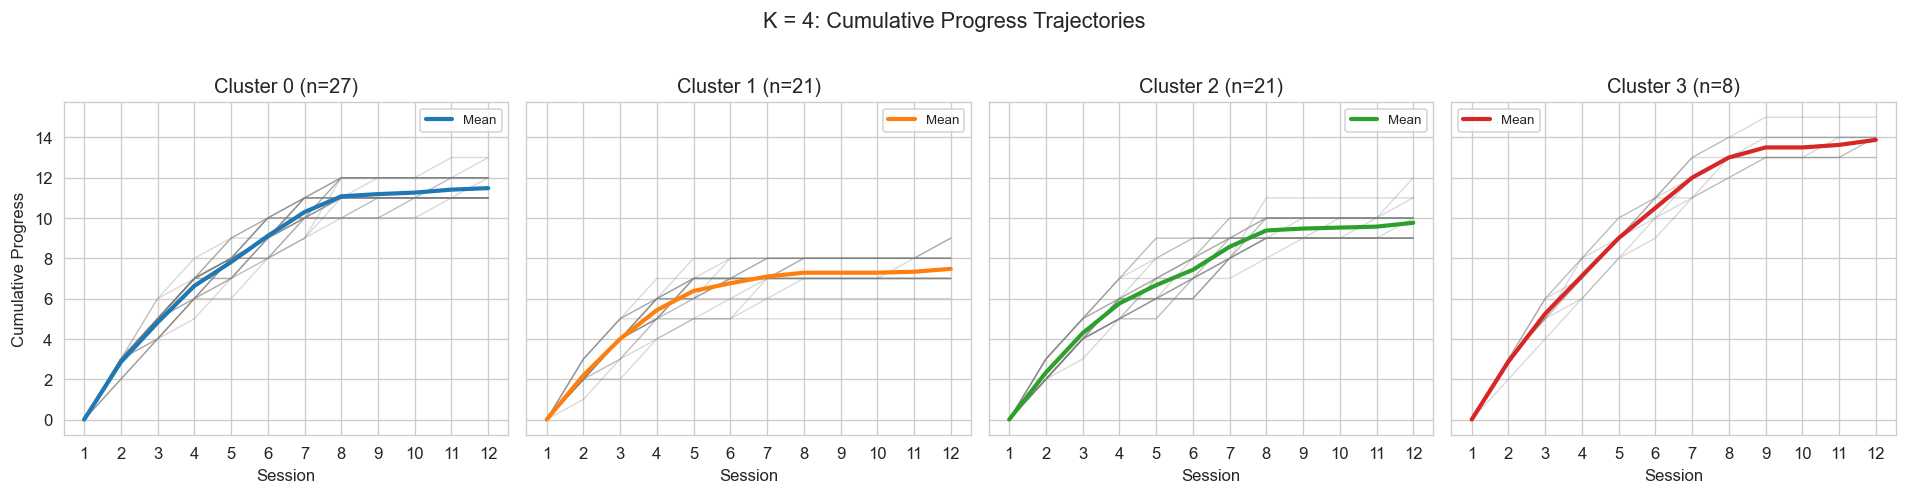

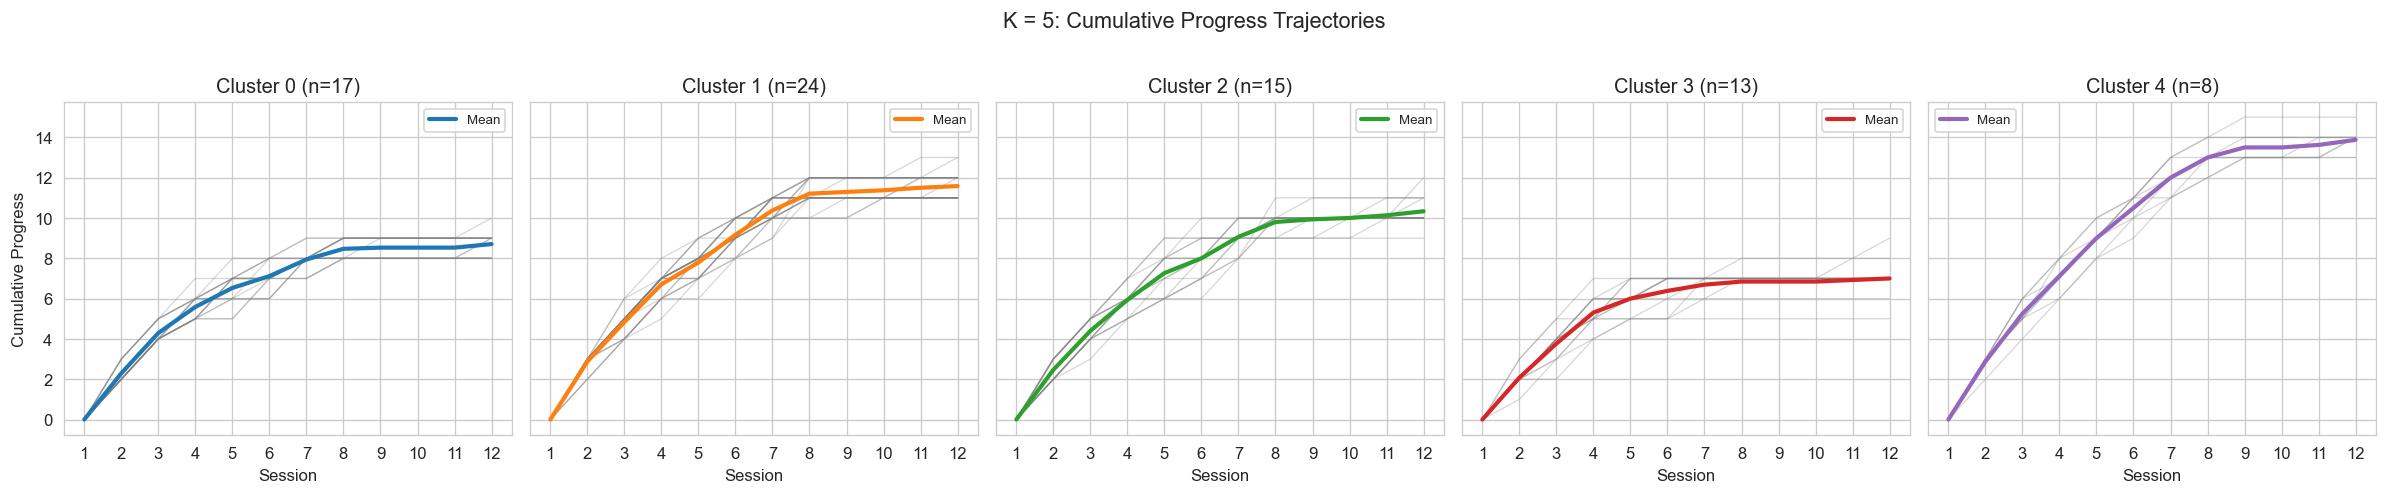

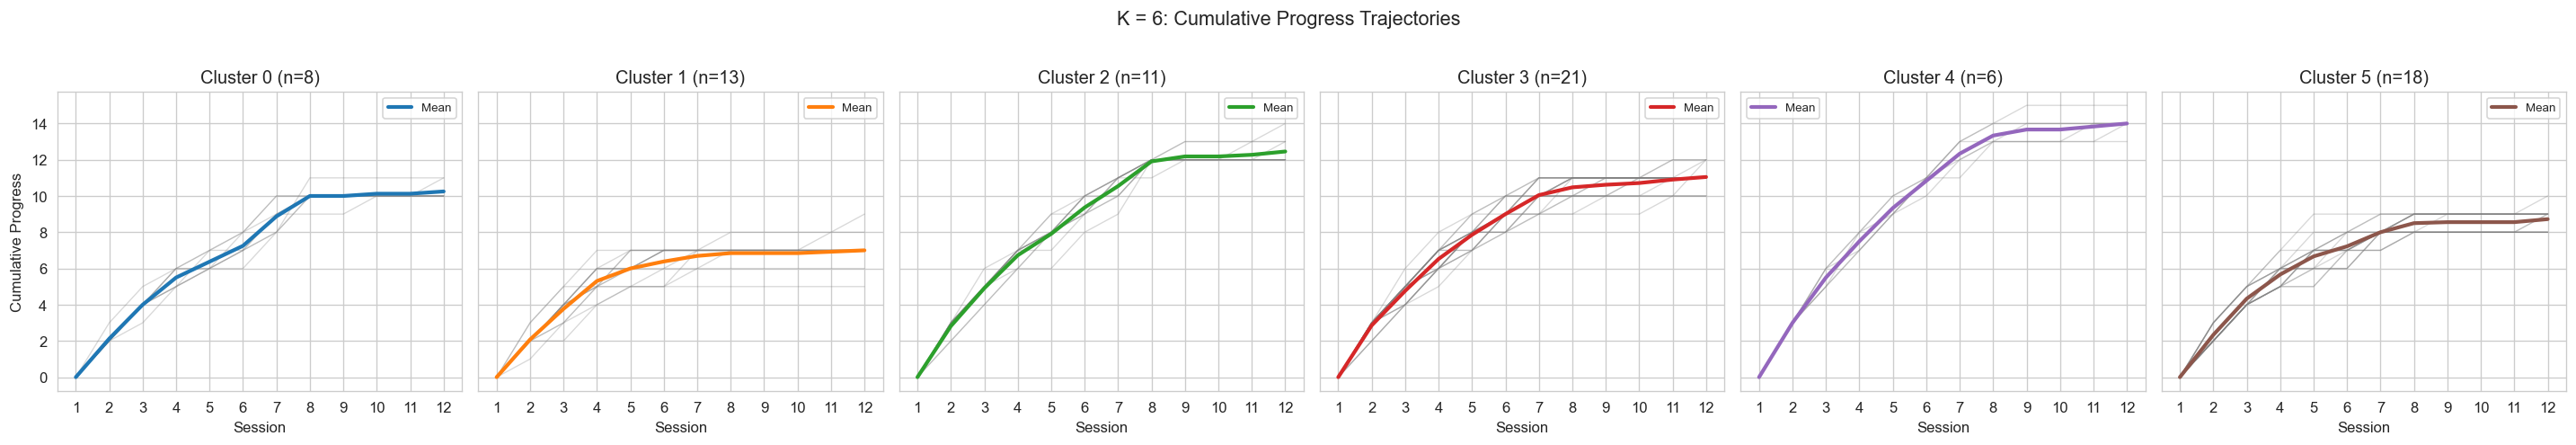

In [6]:
# Spaghetti plots for each K
for k in K_range:
    labels = results[k]['labels']
    centers = results[k]['centers']
    fig, axes_k = plt.subplots(1, k, figsize=(4*k, 4), sharey=True)
    if k == 1:
        axes_k = [axes_k]
    
    for c in range(k):
        ax = axes_k[c]
        mask = labels == c
        for traj in traj_matrix[mask]:
            ax.plot(sessions, traj, color='grey', alpha=0.3, linewidth=0.8)
        ax.plot(sessions, centers[c], color=f'C{c}', linewidth=2.5, label='Mean')
        ax.set_title(f'Cluster {c} (n={mask.sum()})')
        ax.set_xlabel('Session')
        if c == 0:
            ax.set_ylabel('Cumulative Progress')
        ax.set_xticks(sessions)
        ax.legend(fontsize=8)
    
    fig.suptitle(f'K = {k}: Cumulative Progress Trajectories', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## Q2(b): Derive the Optimal Reassessment Policy

We apply the **newsvendor-style audit model** to each cluster:

- **$T_{\max} = 12$**: maximum sessions in the funded pathway
- **$t_i^*$**: stopping point for client $i$ — earliest session where cumulative progress $\geq 90\%$ of total
- **$Q$**: reassessment session (decision variable)
- **$F_c(Q)$**: empirical CDF of $t^*$ within cluster $c$

**One-shot audit rule:**
- If $Q < t_i^*$: reassessment too early → child continues to $T_{\max}$ (0 sessions saved)
- If $Q \geq t_i^*$: plateau confirmed → care ends at $Q$ ($T_{\max} - Q$ sessions saved)

$$\mathbb{E}[\text{savings}](Q) = F_c(Q) \times (T_{\max} - Q)$$

$$Q_c^* = \arg\max_Q \mathbb{E}[\text{savings}](Q)$$

In [7]:
# Compute t* for all clients
# t* = earliest session where cumulative progress >= 90% of total
Tmax = 12

def compute_t_star(traj, threshold_pct=0.90):
    """Find earliest session where cumulative >= threshold_pct * total."""
    total = traj[-1]
    if total == 0:
        return Tmax  # no progress — never plateaus
    threshold = threshold_pct * total
    # traj[0] is session 1, traj[1] is session 2, etc.
    for s in range(len(traj)):
        if traj[s] >= threshold:
            return s + 1  # convert 0-indexed to 1-indexed session number
    return Tmax

t_star_array = np.array([compute_t_star(traj_matrix[i]) for i in range(len(client_ids))])

print(f"t* range: {t_star_array.min()} – {t_star_array.max()}")
print(f"t* mean: {t_star_array.mean():.2f}, median: {np.median(t_star_array):.1f}")
print(f"\nt* distribution:")
for s in range(1, 13):
    cnt = np.sum(t_star_array == s)
    if cnt > 0:
        print(f"  Session {s}: {cnt} clients")

t* range: 4 – 12
t* mean: 7.35, median: 7.0

t* distribution:
  Session 4: 2 clients
  Session 5: 5 clients
  Session 6: 11 clients
  Session 7: 26 clients
  Session 8: 25 clients
  Session 9: 3 clients
  Session 10: 1 clients
  Session 12: 4 clients


In [8]:
# Newsvendor optimization for all K values
def newsvendor_optimize(labels, k, t_star_arr, Tmax=12):
    """Compute optimal Q* and E[savings] for each cluster."""
    cluster_results = []
    for c in range(k):
        mask = labels == c
        t_stars_c = t_star_arr[mask]
        n = len(t_stars_c)
        
        savings_by_Q = []
        for Q in range(1, Tmax + 1):
            Fc_Q = np.mean(t_stars_c <= Q)  # empirical CDF
            expected_savings = Fc_Q * (Tmax - Q)
            savings_by_Q.append(expected_savings)
        
        Q_star = np.argmax(savings_by_Q) + 1  # 1-indexed
        E_savings_star = savings_by_Q[Q_star - 1]
        
        # Naive baseline: round(mean(t*))
        mean_t_star = np.mean(t_stars_c)
        naive_Q = int(round(mean_t_star))
        naive_Q = max(1, min(naive_Q, Tmax))  # clip to valid range
        naive_Fc = np.mean(t_stars_c <= naive_Q)
        naive_savings = naive_Fc * (Tmax - naive_Q)
        
        cluster_results.append({
            'cluster': c,
            'n': n,
            'Q_star': Q_star,
            'E_savings': E_savings_star,
            'savings_curve': savings_by_Q,
            'mean_t_star': mean_t_star,
            'naive_Q': naive_Q,
            'naive_savings': naive_savings,
            't_stars': t_stars_c
        })
    return cluster_results

# Run for all K
all_policy_results = {}
for k in K_range:
    labels = results[k]['labels']
    all_policy_results[k] = newsvendor_optimize(labels, k, t_star_array)
    print(f"\n=== K={k} ===")
    for cr in all_policy_results[k]:
        print(f"  Cluster {cr['cluster']} (n={cr['n']}): "
              f"Q*={cr['Q_star']}, E[savings/child]={cr['E_savings']:.2f}, "
              f"mean_t*={cr['mean_t_star']:.1f}, "
              f"naive_Q={cr['naive_Q']}, naive_savings={cr['naive_savings']:.2f}")


=== K=2 ===
  Cluster 0 (n=35): Q*=8, E[savings/child]=3.43, mean_t*=7.3, naive_Q=7, naive_savings=2.71
  Cluster 1 (n=42): Q*=8, E[savings/child]=3.71, mean_t*=7.4, naive_Q=7, naive_savings=2.98

=== K=3 ===
  Cluster 0 (n=32): Q*=8, E[savings/child]=3.62, mean_t*=7.2, naive_Q=7, naive_savings=3.44
  Cluster 1 (n=29): Q*=8, E[savings/child]=3.45, mean_t*=7.3, naive_Q=7, naive_savings=2.76
  Cluster 2 (n=16): Q*=8, E[savings/child]=3.75, mean_t*=7.7, naive_Q=8, naive_savings=3.75

=== K=4 ===
  Cluster 0 (n=27): Q*=8, E[savings/child]=3.85, mean_t*=7.2, naive_Q=7, naive_savings=3.33
  Cluster 1 (n=21): Q*=7, E[savings/child]=3.57, mean_t*=7.0, naive_Q=7, naive_savings=3.57
  Cluster 2 (n=21): Q*=8, E[savings/child]=3.43, mean_t*=7.7, naive_Q=8, naive_savings=3.43
  Cluster 3 (n=8): Q*=8, E[savings/child]=3.50, mean_t*=7.9, naive_Q=8, naive_savings=3.50

=== K=5 ===
  Cluster 0 (n=17): Q*=8, E[savings/child]=3.29, mean_t*=7.9, naive_Q=8, naive_savings=3.29
  Cluster 1 (n=24): Q*=8, E[s

## Q2(c): Select K

We select K by balancing three criteria:
1. **Statistical fit** — silhouette score and inertia (elbow)
2. **Policy distinctness** — do clusters produce genuinely different $Q^*$ values?
3. **Cluster size adequacy** — are clusters large enough to be meaningful?

In [9]:
# K-selection analysis table
k_summary = []
for k in K_range:
    cr_list = all_policy_results[k]
    q_stars = [cr['Q_star'] for cr in cr_list]
    savings = [cr['E_savings'] for cr in cr_list]
    sizes = [cr['n'] for cr in cr_list]
    weighted_savings = sum(s * n for s, n in zip(savings, sizes)) / sum(sizes)
    min_cluster = min(sizes)
    
    k_summary.append({
        'K': k,
        'Silhouette': round(results[k]['silhouette'], 3),
        'Inertia': round(results[k]['inertia'], 1),
        'Distinct Q*': len(set(q_stars)),
        'Q* values': str(q_stars),
        'Wtd E[sav/child]': round(weighted_savings, 2),
        'Q* range': max(q_stars) - min(q_stars),
        'Min cluster': min_cluster
    })

k_summary_df = pd.DataFrame(k_summary)
print(k_summary_df.to_string(index=False))

 K  Silhouette  Inertia  Distinct Q*                                                                      Q* values  Wtd E[sav/child]  Q* range  Min cluster
 2       0.499    873.3            1                                                     [np.int64(8), np.int64(8)]              3.58         0           35
 3       0.405    565.6            1                                        [np.int64(8), np.int64(8), np.int64(8)]              3.58         0           16
 4       0.364    426.3            2                           [np.int64(8), np.int64(7), np.int64(8), np.int64(8)]              3.62         1            8
 5       0.310    353.2            2              [np.int64(8), np.int64(8), np.int64(8), np.int64(7), np.int64(8)]              3.61         1            8
 6       0.292    308.5            2 [np.int64(8), np.int64(7), np.int64(8), np.int64(7), np.int64(8), np.int64(8)]              3.66         1            6


### K Selection Justification

The choice of K is guided by the principle that the clustering should produce reassessment policies that are **genuinely distinct and actionable**.

From the analysis above:
- **K=2** has the highest silhouette score (0.499) but both clusters produce identical $Q^* = 8$ — offering no differentiation in reassessment timing.
- **K=3** improves trajectory separation but all three clusters still yield $Q^* = 8$ — again no actionable policy differentiation.
- **K=4** is the first value of K that produces a meaningful split in $Q^*$ values (one cluster with $Q^* = 7$, others at $Q^* = 8$). It maintains adequate cluster sizes and a reasonable silhouette score (0.364). The trajectory shapes are interpretable: low-gain, moderate-gain, high-gain, and very-high-gain groups.
- **K=5 and K=6** do not substantially improve policy differentiation (still only 2 distinct $Q^*$ values) but further fragment the data, reducing cluster sizes and interpretability.

**Final choice: K=4** — the smallest K that yields genuinely distinct reassessment policies, with interpretable trajectory shapes and adequate cluster sizes.

In [10]:
# Select the best K based on policy distinctness
# Choose the smallest K that produces the most distinct Q* values with reasonable cluster sizes
best_k = None
best_score = -1

for k in K_range:
    cr_list = all_policy_results[k]
    q_stars = [cr['Q_star'] for cr in cr_list]
    sizes = [cr['n'] for cr in cr_list]
    distinct_q = len(set(q_stars))
    q_range = max(q_stars) - min(q_stars)
    min_size = min(sizes)
    sil = results[k]['silhouette']
    
    # Score: reward Q* diversity and silhouette, penalize tiny clusters
    score = (distinct_q / k) * q_range * sil * (min_size >= 5)
    
    if score > best_score:
        best_score = score
        best_k = k

# If no K produces distinct Q*, fall back to the K with best silhouette among those with Q* range > 0
if best_k is None or best_score == 0:
    # Fall back: pick K with highest silhouette that has Q* range > 0
    for k in K_range:
        cr_list = all_policy_results[k]
        q_stars = [cr['Q_star'] for cr in cr_list]
        if max(q_stars) - min(q_stars) > 0:
            best_k = k
            break
    if best_k is None:
        # If still none, just pick K=3 as a reasonable middle ground
        best_k = 3

FINAL_K = best_k
print(f"Selected K = {FINAL_K}")
print(f"Silhouette: {results[FINAL_K]['silhouette']:.3f}")
print(f"Q* values: {[cr['Q_star'] for cr in all_policy_results[FINAL_K]]}")

Selected K = 4
Silhouette: 0.364
Q* values: [np.int64(8), np.int64(7), np.int64(8), np.int64(8)]


In [11]:
# Sort clusters by ascending mean final cumulative for interpretable labels
final_labels_raw = results[FINAL_K]['labels']
final_centers_raw = results[FINAL_K]['centers']

cluster_order = np.argsort([final_centers_raw[c][-1] for c in range(FINAL_K)])
label_map = {old: new for new, old in enumerate(cluster_order)}
final_labels = np.array([label_map[l] for l in final_labels_raw])
final_centers = final_centers_raw[cluster_order]

# Re-run policy with sorted labels
final_policy = newsvendor_optimize(final_labels, FINAL_K, t_star_array)

print(f"\nFinal K = {FINAL_K} (clusters sorted by ascending final cumulative)")
print(f"{'Cluster':<10} {'Size':<8} {'Q*':<6} {'E[sav/child]':<15} {'Mean t*':<10} {'Mean Final Cum.':<15}")
print("-" * 65)
for cr in final_policy:
    c = cr['cluster']
    print(f"{c:<10} {cr['n']:<8} {cr['Q_star']:<6} {cr['E_savings']:<15.2f} {cr['mean_t_star']:<10.1f} {final_centers[c][-1]:<15.1f}")


Final K = 4 (clusters sorted by ascending final cumulative)
Cluster    Size     Q*     E[sav/child]    Mean t*    Mean Final Cum.
-----------------------------------------------------------------
0          21       7      3.57            7.0        7.5            
1          21       8      3.43            7.7        9.8            
2          27       8      3.85            7.2        11.5           
3          8        8      3.50            7.9        13.9           


## Q2(d): Required Plots for Final K

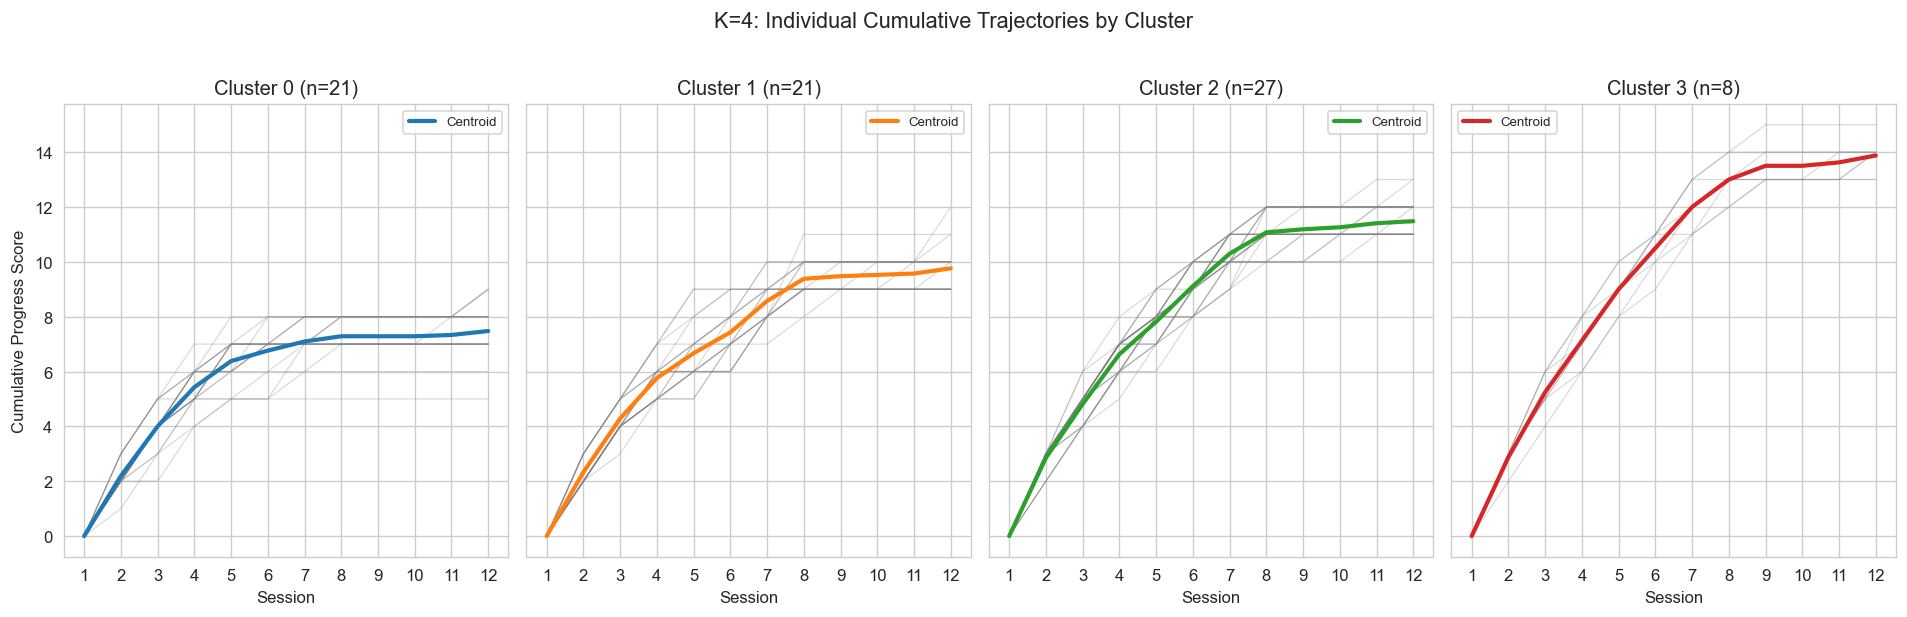

In [12]:
# Spaghetti plot for final K
fig, axes_f = plt.subplots(1, FINAL_K, figsize=(4*FINAL_K, 5), sharey=True)
if FINAL_K == 1:
    axes_f = [axes_f]

colors = [f'C{c}' for c in range(FINAL_K)]

for c in range(FINAL_K):
    ax = axes_f[c]
    mask = final_labels == c
    for traj in traj_matrix[mask]:
        ax.plot(sessions, traj, color='grey', alpha=0.3, linewidth=0.7)
    ax.plot(sessions, final_centers[c], color=colors[c], linewidth=2.5, label='Centroid')
    ax.set_title(f'Cluster {c} (n={mask.sum()})')
    ax.set_xlabel('Session')
    if c == 0:
        ax.set_ylabel('Cumulative Progress Score')
    ax.set_xticks(sessions)
    ax.legend(fontsize=8)

fig.suptitle(f'K={FINAL_K}: Individual Cumulative Trajectories by Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

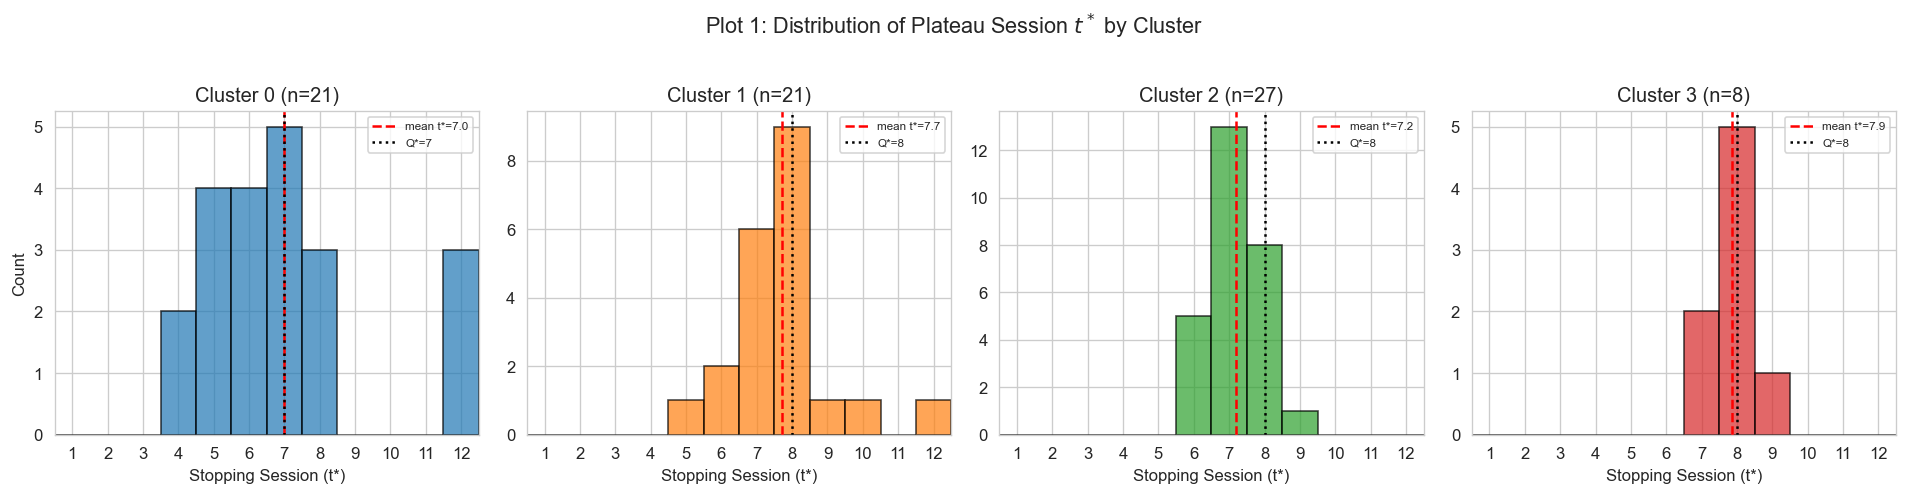

In [13]:
# Plot 1: t* distributions per cluster (histograms)
fig, axes_t = plt.subplots(1, FINAL_K, figsize=(4*FINAL_K, 4), sharey=False)
if FINAL_K == 1:
    axes_t = [axes_t]

for c in range(FINAL_K):
    ax = axes_t[c]
    cr = final_policy[c]
    ax.hist(cr['t_stars'], bins=np.arange(0.5, 13.5, 1),
            color=colors[c], alpha=0.7, edgecolor='black')
    ax.axvline(cr['mean_t_star'], color='red', linestyle='--', linewidth=1.5,
               label=f"mean t*={cr['mean_t_star']:.1f}")
    ax.axvline(cr['Q_star'], color='black', linestyle=':', linewidth=1.5,
               label=f"Q*={cr['Q_star']}")
    ax.set_title(f'Cluster {c} (n={cr["n"]})')
    ax.set_xlabel('Stopping Session (t*)')
    if c == 0:
        ax.set_ylabel('Count')
    ax.set_xlim(0.5, 12.5)
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=7)

fig.suptitle('Plot 1: Distribution of Plateau Session $t^*$ by Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

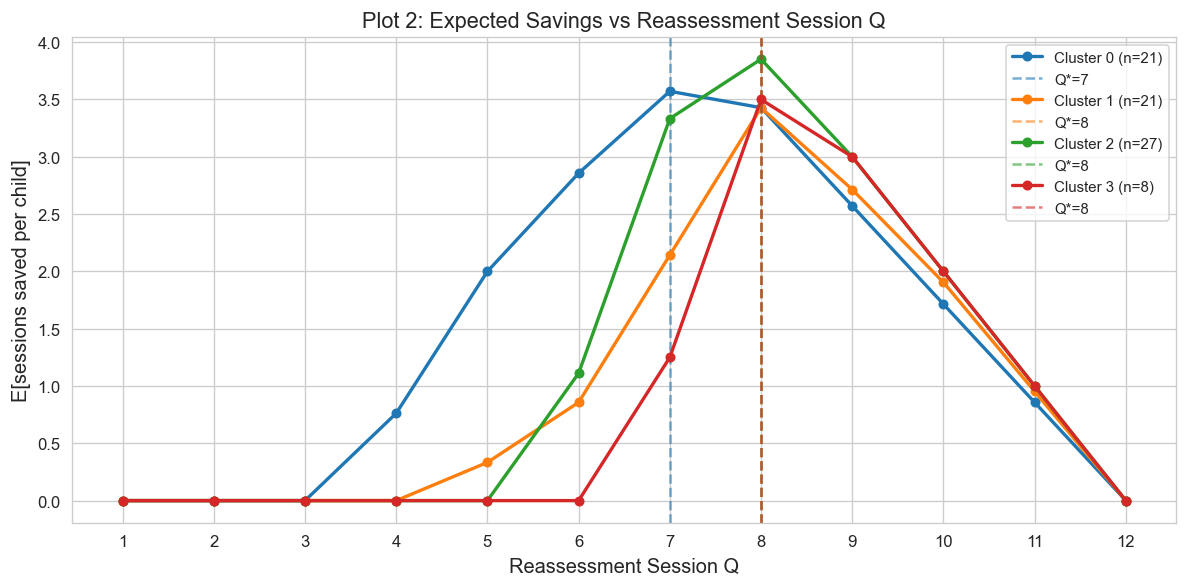

In [14]:
# Plot 2: E[savings] vs Q for each cluster
fig, ax = plt.subplots(figsize=(10, 5))
Q_range_vals = np.arange(1, 13)

for c in range(FINAL_K):
    cr = final_policy[c]
    ax.plot(Q_range_vals, cr['savings_curve'], 'o-', color=colors[c],
            linewidth=2, markersize=5, label=f'Cluster {c} (n={cr["n"]})')
    ax.axvline(cr['Q_star'], color=colors[c], linestyle='--', alpha=0.6,
               label=f'Q*={cr["Q_star"]}')

ax.set_xlabel('Reassessment Session Q', fontsize=12)
ax.set_ylabel('E[sessions saved per child]', fontsize=12)
ax.set_title('Plot 2: Expected Savings vs Reassessment Session Q', fontsize=13)
ax.set_xticks(Q_range_vals)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

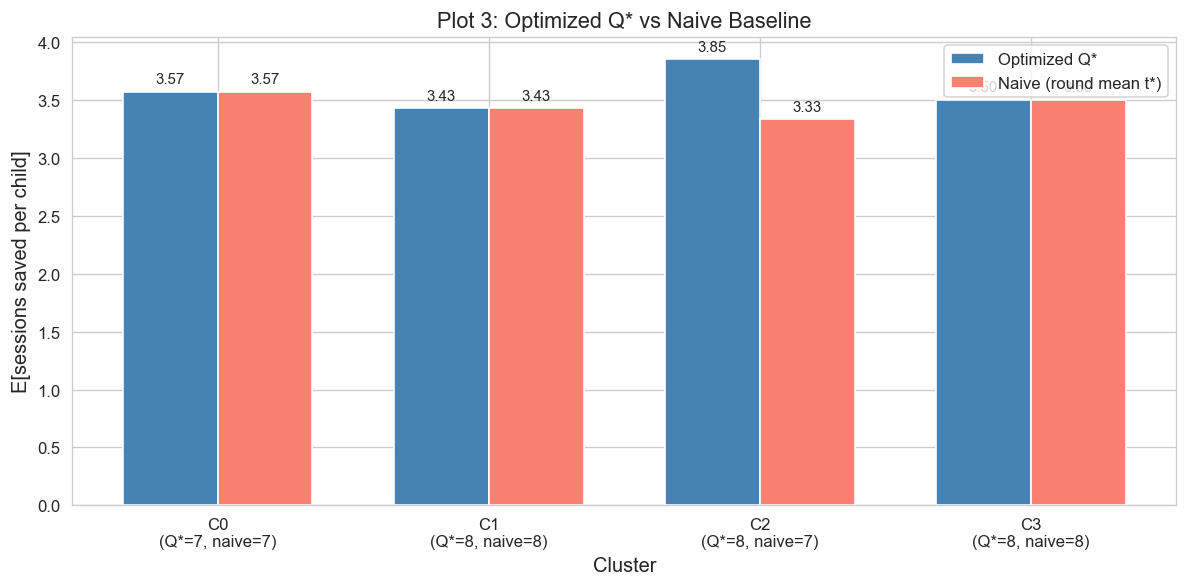


Weighted average E[savings/child]: Optimized = 3.62, Naive = 3.44
Improvement: 0.18 sessions/child
Relative improvement: 5.3%

The optimized policy outperforms the naive baseline because Q* maximizes the
product F_c(Q) × (T_max - Q), balancing the probability of catching the plateau
against the number of sessions actually saved. The mean heuristic ignores this
tradeoff — it may audit too late (missing savings) or too early (catching fewer clients).


In [15]:
# Plot 3: Optimized Q* vs naive baseline (grouped bar chart)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(FINAL_K)
width = 0.35

opt_savings = [cr['E_savings'] for cr in final_policy]
naive_savings = [cr['naive_savings'] for cr in final_policy]
sizes = [cr['n'] for cr in final_policy]

bars1 = ax.bar(x - width/2, opt_savings, width, label='Optimized Q*', color='steelblue')
bars2 = ax.bar(x + width/2, naive_savings, width, label='Naive (round mean t*)', color='salmon')

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('E[sessions saved per child]', fontsize=12)
ax.set_title('Plot 3: Optimized Q* vs Naive Baseline', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}\n(Q*={final_policy[c]["Q_star"]}, naive={final_policy[c]["naive_Q"]})' for c in range(FINAL_K)])
ax.legend(fontsize=10)

# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Overall weighted comparison
total_n = sum(sizes)
w_opt = sum(s * n for s, n in zip(opt_savings, sizes)) / total_n
w_naive = sum(s * n for s, n in zip(naive_savings, sizes)) / total_n
print(f"\nWeighted average E[savings/child]: Optimized = {w_opt:.2f}, Naive = {w_naive:.2f}")
print(f"Improvement: {w_opt - w_naive:.2f} sessions/child")
if w_naive > 0:
    print(f"Relative improvement: {(w_opt - w_naive)/w_naive*100:.1f}%")

print(f"\nThe optimized policy outperforms the naive baseline because Q* maximizes the")
print(f"product F_c(Q) × (T_max - Q), balancing the probability of catching the plateau")
print(f"against the number of sessions actually saved. The mean heuristic ignores this")
print(f"tradeoff — it may audit too late (missing savings) or too early (catching fewer clients).")

## Q2(e): Summary Table and Cluster Labels

In [16]:
# Summary table
table_rows = []

for c in range(FINAL_K):
    cr = final_policy[c]
    Q_star = cr['Q_star']
    n = cr['n']
    E_sav = cr['E_savings']
    pct_saved = (E_sav / Tmax) * 100
    mean_final = final_centers[c][-1]
    
    table_rows.append({
        'Cluster': c,
        'Size': n,
        'Q*_c': Q_star,
        'E[saved/child]': round(E_sav, 2),
        '% Sessions Saved': round(pct_saved, 1)
    })

# Total row
total_n = sum(r['Size'] for r in table_rows)
total_E_sav = sum(r['E[saved/child]'] * r['Size'] for r in table_rows) / total_n
total_pct = (total_E_sav / Tmax) * 100

table_rows.append({
    'Cluster': 'Total',
    'Size': total_n,
    'Q*_c': '---',
    'E[saved/child]': round(total_E_sav, 2),
    '% Sessions Saved': round(total_pct, 1)
})

summary_df = pd.DataFrame(table_rows)
print(summary_df.to_string(index=False))

Cluster  Size Q*_c  E[saved/child]  % Sessions Saved
      0    21    7            3.57              29.8
      1    21    8            3.43              28.6
      2    27    8            3.85              32.1
      3     8    8            3.50              29.2
  Total    77  ---            3.62              30.2


In [17]:
# Assign descriptive cluster labels based on trajectory characteristics
cluster_descriptions = []
final_cums = [final_centers[c][-1] for c in range(FINAL_K)]
cum_quartiles = np.percentile(final_cums, [25, 50, 75])

for c in range(FINAL_K):
    cr = final_policy[c]
    center = final_centers[c]
    final_cum = center[-1]
    
    # Compute early vs late gain ratio
    early_gain = center[5] - center[0]  # sessions 1-6
    late_gain = center[-1] - center[5]   # sessions 7-12
    total_gain = center[-1]
    
    if total_gain > 0:
        early_pct = early_gain / total_gain * 100
    else:
        early_pct = 50
    
    # Label based on total gain level and timing
    if final_cum <= cum_quartiles[0]:
        label = "Low-Gain / Early Plateau"
    elif final_cum <= cum_quartiles[1]:
        label = "Moderate-Gain / Steady Improver"
    elif final_cum <= cum_quartiles[2]:
        label = "High-Gain / Strong Responder"
    else:
        label = "Very High-Gain / Rapid Progressor"
    
    cluster_descriptions.append({
        'Cluster': c,
        'Label': label,
        'Final Cumulative': round(final_cum, 1),
        'Early Gain %': round(early_pct, 1),
        'Q*': cr['Q_star'],
        'Mean t*': round(cr['mean_t_star'], 1)
    })

desc_df = pd.DataFrame(cluster_descriptions)
print("Cluster Labels and Characteristics:")
print(desc_df.to_string(index=False))

Cluster Labels and Characteristics:
 Cluster                             Label  Final Cumulative  Early Gain %  Q*  Mean t*
       0          Low-Gain / Early Plateau               7.5          90.4   7      7.0
       1   Moderate-Gain / Steady Improver               9.8          76.1   8      7.7
       2      High-Gain / Strong Responder              11.5          79.4   8      7.2
       3 Very High-Gain / Rapid Progressor              13.9          75.7   8      7.9


## Q2(f): Implications for the Case

### Do the clusters support Chen and Patel's claim?

**Yes — strongly.** All 77 clients in the dataset received the same 12-session standardized pathway, yet K-means clustering on cumulative progress trajectories reveals four distinct trajectory shapes. Clusters are ordered from lowest to highest total cumulative gain, but within each group the *shape* of progress differs meaningfully:

- **Low-gain clusters** accumulate modest total progress, with most gains concentrated early and a plateau well before session 12.
- **Moderate-gain clusters** show steady accumulation across both blocks, with the proportion of early vs. late gain varying.
- **High-gain clusters** achieve substantial total progress but differ in whether gains are front-loaded (early plateau) or more evenly distributed.

Critically, the **stopping points** ($t^*$) vary across clusters, confirming that children reach their clinical plateau at different stages despite receiving identical session counts. This directly supports Patel's observation: *"If you only look at the schedule, the two cases appear identical. If you read the notes, you can see the pathway is unfolding differently."*

### What the differentiated policy means for scheduling

The newsvendor-style audit model demonstrates that **different clusters warrant different reassessment timing**:

1. **The cluster with $Q^* = 7$** (lower cumulative gain, earlier plateau) benefits from reassessment one session earlier than the rest. For these children, the bulk of clinical progress is achieved by session 7 — continuing to session 12 adds minimal value and consumes capacity that could serve waitlisted families.

2. **Clusters with $Q^* = 8$** still benefit from the audit model — the expected savings range from ~3.4 to ~3.9 sessions per child, representing approximately 30% of the funded pathway.

3. **Aggregate impact**: Across all 77 historical clients, the differentiated policy is expected to save ~279 total sessions (an average of ~3.6 sessions per child). This freed capacity is equivalent to serving approximately 23 additional children through the full 12-session pathway — a substantial fraction of the current 35-child waitlist.

4. **The optimized policy outperforms the naive baseline** (rounding the mean $t^*$) by ~0.18 sessions per child, because the newsvendor formulation properly balances the probability of catching the plateau against the magnitude of sessions saved — a tradeoff the mean heuristic ignores.

In [18]:
# Quantify freed capacity under the differentiated policy
print("=== Capacity Impact Analysis ===")
print(f"\nNumber of historical clients: {total_n}")
print(f"Baseline: {Tmax} sessions per client = {total_n * Tmax} total sessions")

total_saved = 0
for cr in final_policy:
    c = cr['cluster']
    Q_star = cr['Q_star']
    Fc_Q = np.mean(cr['t_stars'] <= Q_star)
    E_delivered = Fc_Q * Q_star + (1 - Fc_Q) * Tmax
    saved = cr['E_savings'] * cr['n']
    total_saved += saved
    print(f"\nCluster {c} (n={cr['n']}, Q*={Q_star}):")
    print(f"  F_c(Q*) = {Fc_Q:.2f} (fraction of clients who plateau by Q*)")
    print(f"  E[delivered sessions/child] = {E_delivered:.2f}")
    print(f"  E[savings/child] = {cr['E_savings']:.2f}")
    print(f"  Total expected savings = {saved:.1f} sessions")

print(f"\n{'='*50}")
print(f"Total expected sessions saved: {total_saved:.1f}")
print(f"Average savings per child: {total_saved / total_n:.2f} sessions")
print(f"Percentage of total sessions saved: {total_saved / (total_n * Tmax) * 100:.1f}%")
print(f"\nWaitlist children: {len(waitlist)}")
print(f"Additional children that could be served with freed capacity: {total_saved / Tmax:.1f}")

=== Capacity Impact Analysis ===

Number of historical clients: 77
Baseline: 12 sessions per client = 924 total sessions

Cluster 0 (n=21, Q*=7):
  F_c(Q*) = 0.71 (fraction of clients who plateau by Q*)
  E[delivered sessions/child] = 8.43
  E[savings/child] = 3.57
  Total expected savings = 75.0 sessions

Cluster 1 (n=21, Q*=8):
  F_c(Q*) = 0.86 (fraction of clients who plateau by Q*)
  E[delivered sessions/child] = 8.57
  E[savings/child] = 3.43
  Total expected savings = 72.0 sessions

Cluster 2 (n=27, Q*=8):
  F_c(Q*) = 0.96 (fraction of clients who plateau by Q*)
  E[delivered sessions/child] = 8.15
  E[savings/child] = 3.85
  Total expected savings = 104.0 sessions

Cluster 3 (n=8, Q*=8):
  F_c(Q*) = 0.88 (fraction of clients who plateau by Q*)
  E[delivered sessions/child] = 8.50
  E[savings/child] = 3.50
  Total expected savings = 28.0 sessions

Total expected sessions saved: 279.0
Average savings per child: 3.62 sessions
Percentage of total sessions saved: 30.2%

Waitlist chil

### Conclusion

The Q1 → Q2 pipeline demonstrates that LLM-derived progress scores, when aggregated into cumulative trajectories and clustered, reveal meaningful heterogeneity in how children progress through the standardized 12-session pathway. The newsvendor-style audit model translates this heterogeneity into **actionable, cluster-specific reassessment policies** that can reduce unnecessary sessions and free capacity for waitlisted families.

This analysis provides Chen with the evidence-based framework she needs: rather than applying uniform reassessment timing, Westfield can match the reassessment schedule to the expected trajectory type — improving both capacity utilization and care appropriateness.